In [1]:
!export CUDA_VISIBLE_DEVICES=3

import torch
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from src.models.our_method.swin_cafm import SwinCAFM

warnings.simplefilter("ignore")
BEST_FP = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/substrates/silicon/2x/2025-02-24_13-16-05_SwinIR-SR-2X-DS=MoS2-sil-downsampling=bicubic-s64-bs-1-adam-lr=1e-6-loss=L1/SwinIR-SR-2X-DS=MoS2-sil-downsampling=bicubic-s64-bs-1-adam-lr=1e-6-loss=L1_latest.pth"
model: SwinCAFM = torch.load(BEST_FP).cuda().float(); model.eval();

/home/mufan/miniforge3/envs/control/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mufan/miniforge3/envs/control/lib/python3.8/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
from src.datasets.mos2_sr import MOS2SRDataset, MOS2_SEF_SRC_DIR, MOS2_SAPPHIRE_DIR, MOS2_SILICON_DIR

dataset_name = BEST_FP.split("/")[-4]
src_dir = ""
if dataset_name == "mos2-sef": src_dir = MOS2_SEF_SRC_DIR
if dataset_name == "sapphire": src_dir = MOS2_SAPPHIRE_DIR
if dataset_name == "silicon": src_dir = MOS2_SILICON_DIR
upsampling_factor = int(BEST_FP.split("SR-")[1:][0][0])

dataset = MOS2SRDataset(
    src_dir=src_dir, 
    split="val", 
    upsample_factor=upsampling_factor
)

In [4]:
def undo_min_max_scaling(x):
    return x * (dataset.current_maps_max - dataset.current_maps_min) + dataset.current_maps_min

y    : torch.Tensor = original_data.cuda()
y_hat: torch.Tensor = torch.Tensor(pred).cuda().squeeze(0)

mae = torch.nn.functional.l1_loss(y, y_hat).item()
percent_err = ((torch.nn.functional.l1_loss(y, y_hat) / y.mean()) * 100).item()
r2_err = compute_r2(y_hat, y)

print(f"{mae:2f}", f"{percent_err:2f}", f"{r2_err:02f}")

0.007562 7.480614 0.939453


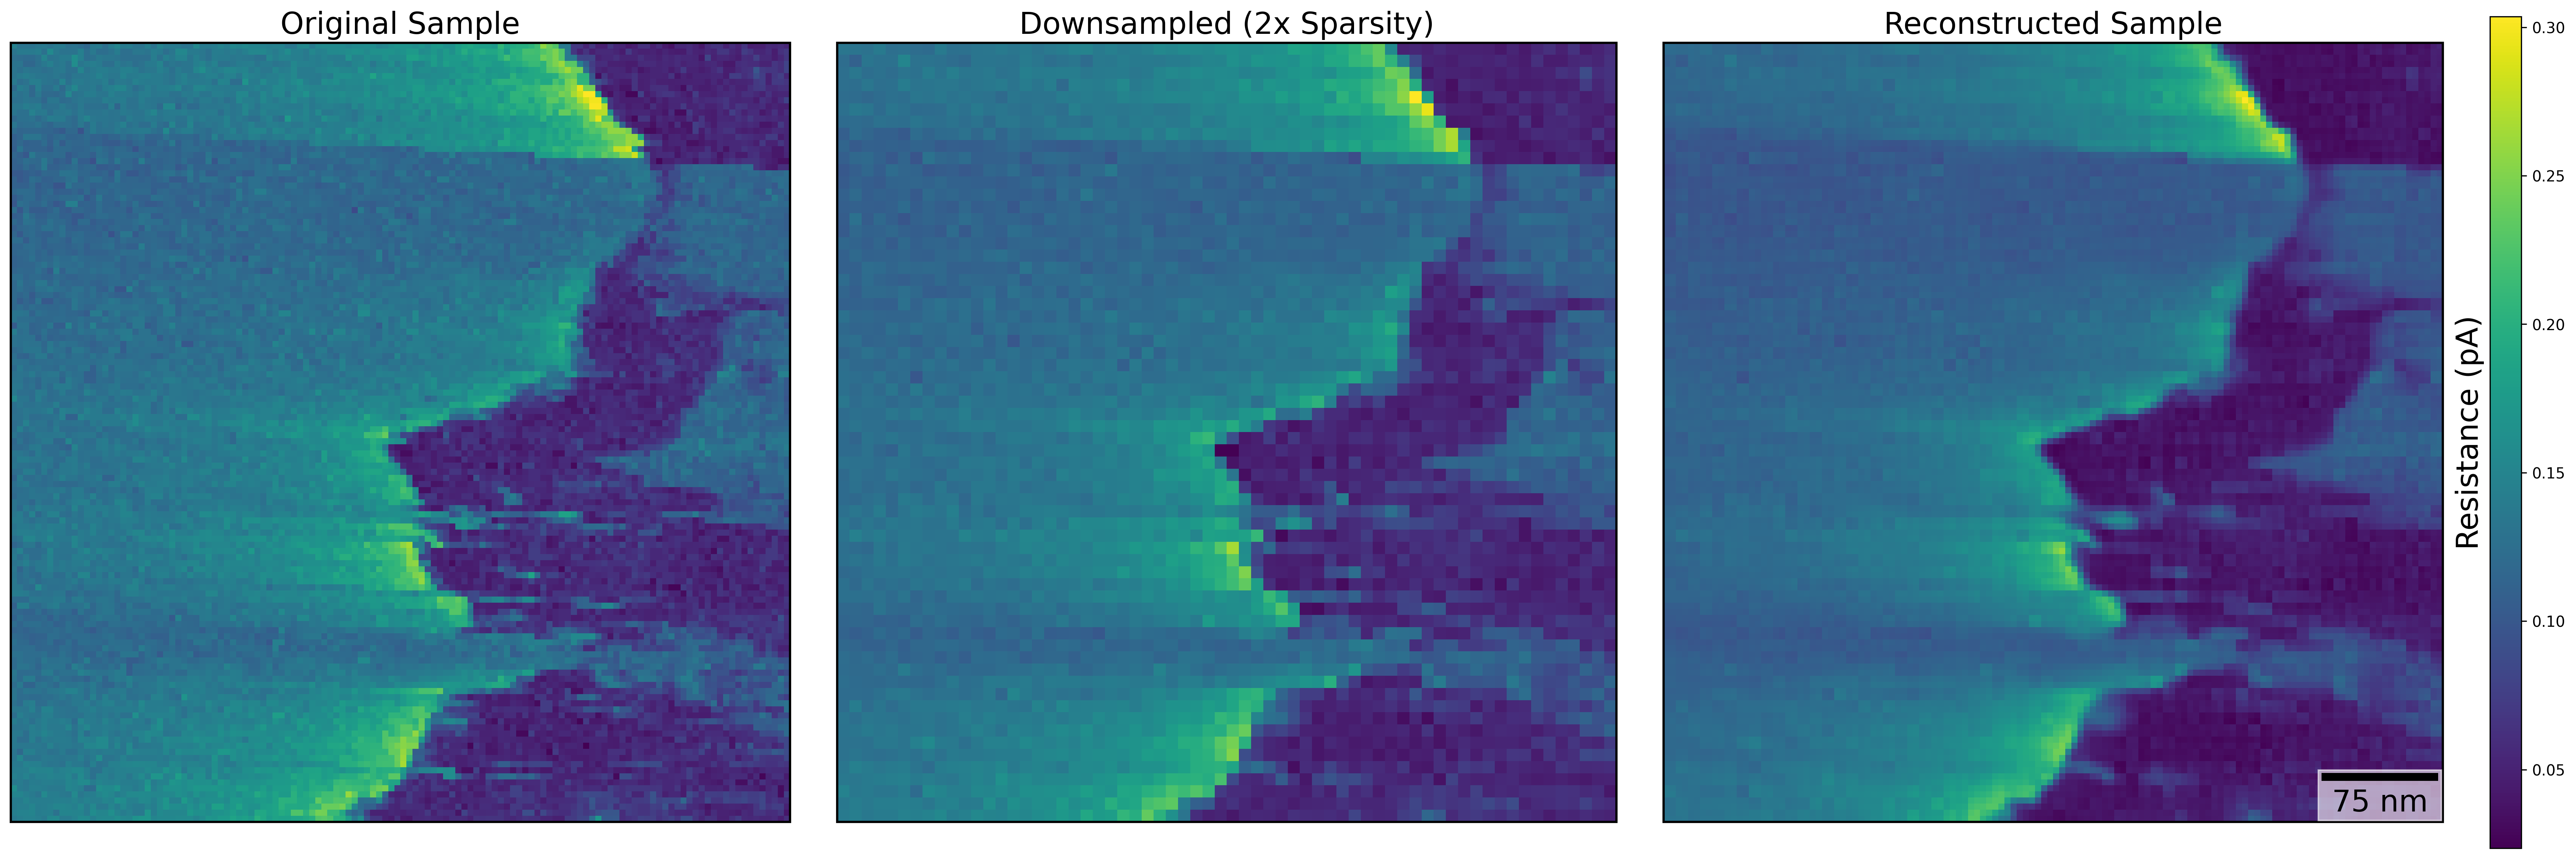

In [5]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
from matplotlib_scalebar.scalebar import ScaleBar

fig = plt.figure(figsize=(30, 10), dpi=300)
# Create a 1×4 grid; the last column is for the colorbar
gs = GridSpec(nrows=1, ncols=4, width_ratios=[1, 1, 1, 0.04], wspace=0.08)

# Make three axes for the images and one axis for the colorbar
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
cax = fig.add_subplot(gs[3])  # dedicated axis for colorbar

font_sz = 20

# --- Plot images on the first three axes ---
im0 = ax0.imshow(original_data, cmap='viridis')
ax0.set_title("Original Sample", fontsize=font_sz)
ax0.axis("off")

im1 = ax1.imshow(downsampled_data.cpu(), cmap='viridis')
ax1.set_title(f"Downsampled ({upsampling_factor}x Sparsity)", fontsize=font_sz)
ax1.axis("off")

im2 = ax2.imshow(pred.detach().squeeze(0).cpu().numpy(), cmap='viridis')
ax2.set_title("Reconstructed Sample", fontsize=font_sz)
ax2.axis("off")

# --- Create the colorbar in its own axis ---
cbar = fig.colorbar(im2, cax=cax)
cbar.set_label("Resistance (pA)", fontsize=font_sz)
# Slant the label diagonally
# cbar.ax.yaxis.label.set_rotation(45)
cbar.ax.yaxis.set_label_position("left")
cbar.ax.yaxis.label.set_verticalalignment("bottom")

# --- Add the scale bar to the third axis ---
pixel_size_um = 2.0 / 512
scalebar = ScaleBar(
    pixel_size_um, "um", 
    location="lower right", 
    color="black", 
    box_alpha=0.60,
    font_properties={"size": 20}
)
ax2.add_artist(scalebar)

# --- Add rectangular borders around the images ---
for ax in [ax0, ax1, ax2]:
    rect = Rectangle(
        xy=(0, 0),
        width=1, 
        height=1, 
        fill=False,
        edgecolor="black", 
        linewidth=1.5,
        transform=ax.transAxes,
        clip_on=False
    )
    ax.add_patch(rect)

plt.tight_layout()
plt.show()